# PROG8431 - Problem Analysis Workshop A
| Name | Student ID | Sections |
|---|---|---|
| Davisen Veerasamy | 8899632 | Setup, Preprocessing, EDA |
| Carlos Gutierrez | 9118300 | Placeholder |
| Nnamdi Ikengah | 9085175 | Placeholder |

**Dataset:** The AI4I 2020 Predictive Maintenance Dataset. It contains 10,000 runs of a milling machine, with five sensor readings per run and a record of whether (and why) the machine failed.

**GitHub Repository:** [https://github.com/DavisenV/Group1-PROG8431-ProblemAnalysis_Workshop_A.git]

## Setup and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import urllib.request
import zipfile
import os

# Plot styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Environment setup and libraries loaded successfully.")

Environment setup and libraries loaded successfully.


## Download, Load, Preprocess and Clean the Dataset

In [ ]:
# Define paths inside a 'data' directory
data_dir = "data"
os.makedirs(data_dir, exist_ok=True)

# UCI AI4I 2020 Predictive Maintenance dataset zip URL
dataset_url = "https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip"
zip_path = os.path.join(data_dir, "predictive_maintenance.zip")
csv_path = os.path.join(data_dir, "predictive_maintenance.csv")

# Download and extract if not present
if not os.path.exists(csv_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print("Extraction complete.")

    extracted_csv_path = os.path.join(data_dir, "ai4i2020.csv")

    if not os.path.exists(extracted_csv_path):
        raise FileNotFoundError(
            f"Expected extracted file was not found: {extracted_csv_path}"
        )

    os.replace(extracted_csv_path, csv_path)
    print(f"Dataset renamed to: {csv_path}")

# Load raw dataset
df = pd.read_csv(csv_path)

# Data Cleaning & Standardization
# 1. Rename columns to cleaner standard Python identifiers
df.columns = [
    'udi', 'product_id', 'type', 'air_temp', 'process_temp', 
    'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 
    'tool_wear', 'heat_dissipation', 'power', 'overstrain', 'random'
]

# 2. Check and handle missing values & duplicates
missing_count = df.isnull().sum().sum()
duplicate_count = df.duplicated().sum()

# 3. Drop unneeded identification columns for statistical modeling
df_clean = df.drop(columns=['udi', 'product_id']).copy()

# 4. Confirm data types
df_clean['type'] = df_clean['type'].astype('category')
df_clean['machine_failure'] = df_clean['machine_failure'].astype(int)

print(f"Dataset Shape: {df_clean.shape}")
print(f"Missing Values: {missing_count}, Duplicates: {duplicate_count}")
df_clean.head()

Dataset Shape: (10000, 12)
Missing Values: 0, Duplicates: 0


,type,air_temp,process_temp,rotational_speed,torque,tool_wear,machine_failure,twf,hdf,pwf,osf,rnf
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Exploratory Data Analysis (EDA)

In [3]:
# Exploratory Data Analysis (EDA)

print("=== 1. Dataset Dimensions & Schema ===")
print(df_clean.info())

print("\n=== 2. Missing Values Check ===")
print(df_clean.isnull().sum())

print("\n=== 3. Summary Statistics for Numeric Features ===")
display(df_clean.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

print("\n=== 4. Target Class Distribution (Machine Failure) ===")
failure_counts = df_clean['machine_failure'].value_counts()
failure_percentages = df_clean['machine_failure'].value_counts(normalize=True) * 100
class_dist = pd.DataFrame({'Count': failure_counts, 'Percentage (%)': failure_percentages})
display(class_dist)

print("\n=== 5. Failure Mode Breakdown ===")
failure_modes = ['twf', 'hdf', 'pwf', 'osf', 'rnf']
display(df_clean[failure_modes].sum().to_frame(name='Failure Occurrences'))

=== 1. Dataset Dimensions & Schema ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   type              10000 non-null  category
 1   air_temp          10000 non-null  float64 
 2   process_temp      10000 non-null  float64 
 3   rotational_speed  10000 non-null  int64   
 4   torque            10000 non-null  float64 
 5   tool_wear         10000 non-null  int64   
 6   machine_failure   10000 non-null  int64   
 7   twf               10000 non-null  int64   
 8   hdf               10000 non-null  int64   
 9   pwf               10000 non-null  int64   
 10  osf               10000 non-null  int64   
 11  rnf               10000 non-null  int64   
dtypes: category(1), float64(3), int64(8)
memory usage: 869.3 KB
None

=== 2. Missing Values Check ===
type                0
air_temp            0
process_temp        0
rotational_speed    0
t

,mean,std,min,25%,50%,75%,max
air_temp,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
process_temp,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
rotational_speed,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
torque,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
tool_wear,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
machine_failure,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0
twf,0.00460,0.067671,0.0,0.0,0.0,0.0,1.0
hdf,0.01150,0.106625,0.0,0.0,0.0,0.0,1.0
pwf,0.00950,0.097009,0.0,0.0,0.0,0.0,1.0
osf,0.00980,0.098514,0.0,0.0,0.0,0.0,1.0



=== 4. Target Class Distribution (Machine Failure) ===


,Count,Percentage (%)
machine_failure,,
0,9661,96.61
1,339,3.39



=== 5. Failure Mode Breakdown ===


,Failure Occurrences
twf,46
hdf,115
pwf,95
osf,98
rnf,19


## Histogram of Sensor Readings

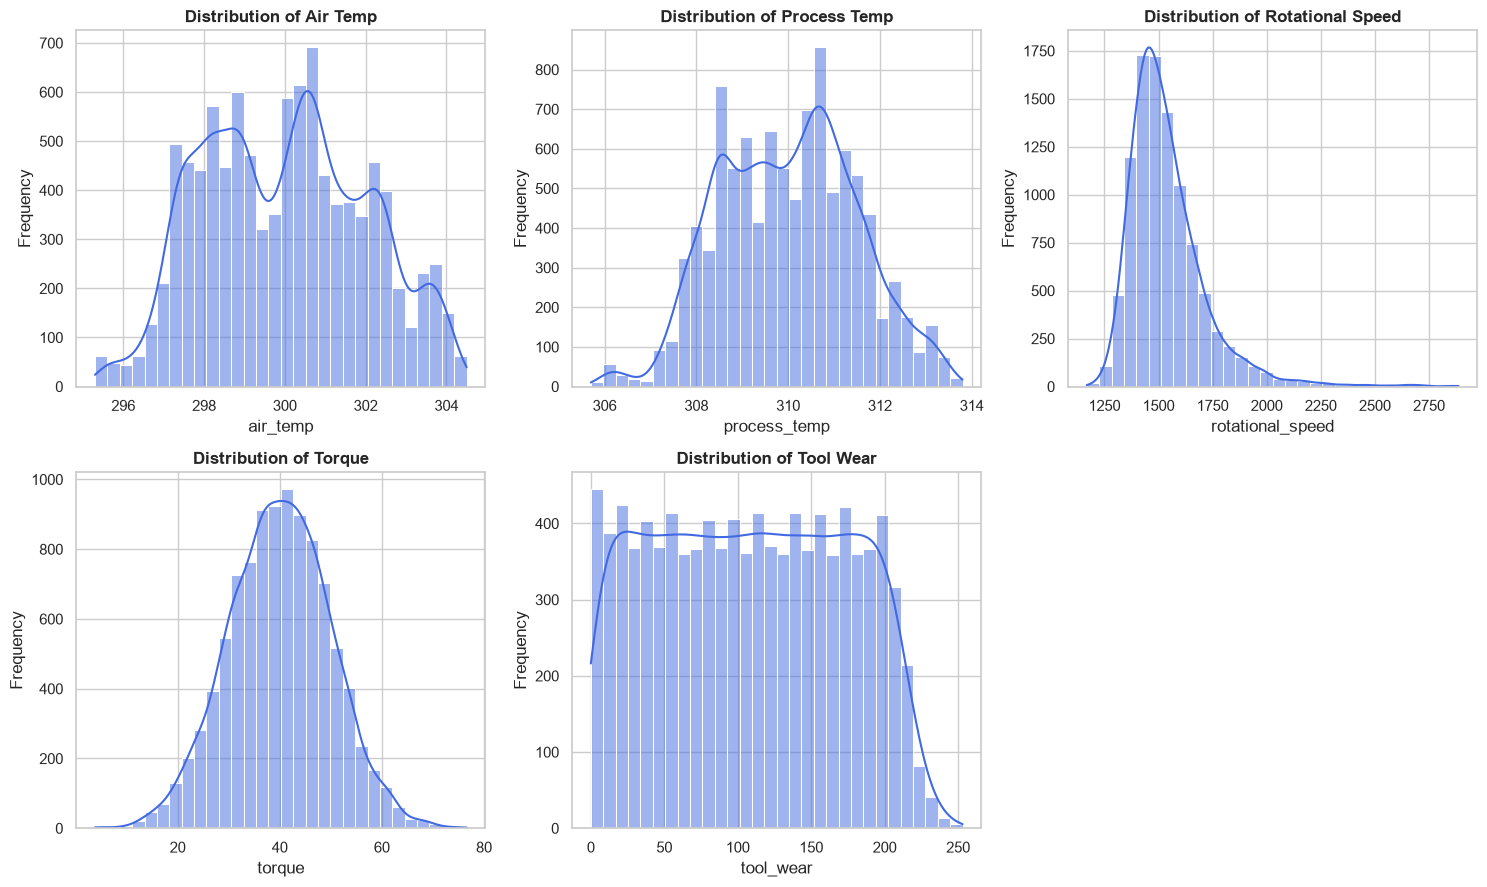

In [5]:
# Select continuous numeric sensor variables
numeric_vars = ['air_temp', 'process_temp', 'rotational_speed', 'torque', 'tool_wear']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_vars):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='royalblue', bins=30)
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove unused 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()